# Market Making: Avellaneda-Stoikov Model

Simulate optimal market making under inventory risk (Avellaneda–Stoikov, 2008): reservation price, optimal half-spread, Poisson fills, and $\gamma$ sensitivity.

**Theory references:** [Avellaneda-Stoikov](../theory/03_market_making/avellaneda_stoikov.md) | [Inventory Risk](../theory/03_market_making/inventory_risk.md) | [Bid-Ask Spread](../theory/03_market_making/bid_ask_spread.md)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'normal',
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556', '#3B6D11', '#BA7517']

import os


def save_fig(fig, topic: str, name: str) -> None:
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))


## Section 1 — Avellaneda-Stoikov Model

### Setup

A market maker observes a mid-price following **arithmetic Brownian motion**:

$$dS_t = \sigma\,dW_t$$

They post a bid quote at $S_t - \delta^b$ and an ask quote at $S_t + \delta^a$. Orders arrive as independent **Poisson processes** with intensities that decay exponentially in the half-spread:

$$\lambda^b(\delta^b) = A\,e^{-\kappa\delta^b}, \qquad \lambda^a(\delta^a) = A\,e^{-\kappa\delta^a}$$

Parameter $\kappa > 0$ governs how quickly order flow drops off with distance; $A > 0$ is the baseline arrival rate. Inventory $q_t \in \mathbb{Z}$ changes by $+1$ on a bid fill and $-1$ on an ask fill. Wealth $X_t$ evolves as $dX_t = (S_t + \delta^a)\,dN^a_t - (S_t - \delta^b)\,dN^b_t$.

### Hamilton–Jacobi–Bellman Equation

The maker maximises expected **CARA utility** at the terminal time $T$:

$$\max_{\delta^b,\,\delta^a} \mathbb{E}\!\left[-e^{-\gamma(X_T + q_T S_T)}\right]$$

The $q_T S_T$ term marks the final inventory to market. With value function $u(x, q, s, t)$, the HJB equation is:

$$\frac{\partial u}{\partial t} + \frac{1}{2}\sigma^2\frac{\partial^2 u}{\partial s^2} + \max_{\delta^b}\left\{\lambda^b(\delta^b)\left[u(x - s + \delta^b,\, q+1,\, s,\, t) - u\right]\right\} + \max_{\delta^a}\left\{\lambda^a(\delta^a)\left[u(x + s + \delta^a,\, q-1,\, s,\, t) - u\right]\right\} = 0$$

### Exponential Ansatz

Substitute $u = -\exp\!\bigl(-\gamma(x + q\,s + \phi(q,t))\bigr)$. Dividing through by $-u > 0$ transforms the HJB into:

$$-\frac{\partial \phi}{\partial t} - \frac{1}{2}\sigma^2\left(\gamma q^2 - \frac{\partial^2\phi}{\partial s^2}\right) + \max_{\delta^b}\!\left\{A e^{-\kappa\delta^b}\!\left(1 - e^{-\gamma(\delta^b - \Delta^+\phi)}\right)\right\} + \max_{\delta^a}\!\left\{A e^{-\kappa\delta^a}\!\left(1 - e^{-\gamma(\delta^a + \Delta^-\phi)}\right)\right\} = 0$$

where $\Delta^\pm\phi = \phi(q\pm 1,t) - \phi(q,t)$ is the discrete inventory increment of $\phi$.

### Reservation Price

Avellaneda & Stoikov propose the **quadratic ansatz** $\phi(q,t) = -\frac{1}{2}\gamma\sigma^2 q^2 (T-t)$, which solves the equation to leading order. This gives the **reservation (indifference) price**:

$$\boxed{r_t = S_t - q_t\,\gamma\,\sigma^2\,(T-t)}$$

Interpretation: if you are **long** ($q > 0$), your indifference price for selling is *below* $S_t$ — you are willing to accept a discount to reduce inventory risk. The discount grows with $q$, $\gamma$, $\sigma^2$, and remaining time $T-t$.

### Optimal Half-Spread

Taking first-order conditions on each side of the maximisation yields a **symmetric** solution $\delta^{b*} = \delta^{a*} \equiv \delta^*$:

$$\frac{\partial}{\partial\delta}\left[A e^{-\kappa\delta}\left(1 - e^{-\gamma\delta}\right)\right] = 0 \implies -\kappa\left(1 - e^{-\gamma\delta}\right) + \gamma\,e^{-\gamma\delta} = 0$$

Solving: $e^{-\gamma\delta^*} = \frac{\kappa}{\kappa + \gamma}$, so $\delta^* = \frac{1}{\gamma}\ln\!\left(1 + \frac{\gamma}{\kappa}\right)$. Adding the inventory risk component:

$$\boxed{\delta^* = \frac{\gamma\sigma^2(T-t)}{2} + \frac{1}{\kappa}\ln\!\left(1 + \frac{\gamma}{\kappa}\right)}$$

The **total quoted spread** $\delta^b + \delta^a = 2\delta^*$ has two components:
- $\gamma\sigma^2(T-t)$ — **inventory risk premium**: widens at open, narrows toward close as the horizon $T - t \to 0$.
- $\frac{2}{\kappa}\ln(1+\gamma/\kappa)$ — **adverse-selection premium**: how much to charge per unit of order-flow intensity regardless of time.1 + \frac{\gamma}{\kappa})$.

Quotes: $\mathrm{bid} = r_t - \delta^*$, $\mathrm{ask} = r_t + \delta^*$.


In [11]:
def simulate_mid_price(S0: float, sigma: float, T: float, n_steps: int,
                       rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Simulate mid-price as arithmetic Brownian motion. Returns (time_grid, prices)."""
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    dW = rng.normal(0.0, np.sqrt(dt), n_steps)
    S = np.empty(n_steps + 1)
    S[0] = S0
    S[1:] = S0 + np.cumsum(sigma * dW)
    return t, S


In [12]:
def avellaneda_stoikov_sim(S0: float, sigma: float, T: float, n_steps: int,
                           gamma: float, kappa: float, A: float,
                           rng: np.random.Generator) -> dict:
    """One trading session: AS quotes, Poisson-style fills, inventory and PnL."""
    dt = T / n_steps
    t, S = simulate_mid_price(S0, sigma, T, n_steps, rng)
    q = np.zeros(n_steps + 1)
    cash = np.zeros(n_steps + 1)
    bid = np.zeros(n_steps + 1)
    ask = np.zeros(n_steps + 1)
    res = np.zeros(n_steps + 1)
    spread_rev = np.zeros(n_steps + 1)
    n_fills = 0
    for i in range(n_steps):
        tau = max(T - t[i], 1e-10)
        r = S[i] - q[i] * gamma * sigma**2 * tau
        half_spread = gamma * sigma**2 * tau / 2.0 + (1.0 / gamma) * np.log(1.0 + gamma / kappa)
        bid_price = r - half_spread
        ask_price = r + half_spread
        res[i] = r
        bid[i] = bid_price
        ask[i] = ask_price
        delta_a = max(ask_price - S[i], 0.0)
        delta_b = max(S[i] - bid_price, 0.0)
        p_ask = min(A * np.exp(-kappa * delta_a) * dt, 1.0)
        p_bid = min(A * np.exp(-kappa * delta_b) * dt, 1.0)
        ask_fill = rng.random() < p_ask
        bid_fill = rng.random() < p_bid
        new_q, new_cash, new_sr = q[i], cash[i], spread_rev[i]
        if ask_fill:
            new_cash += ask_price
            new_q -= 1.0
            new_sr += delta_a
            n_fills += 1
        if bid_fill:
            new_cash -= bid_price
            new_q += 1.0
            new_sr += delta_b
            n_fills += 1
        q[i + 1] = new_q
        cash[i + 1] = new_cash
        spread_rev[i + 1] = new_sr
    res[-1] = S[-1] - q[-1] * gamma * sigma**2 * 1e-10
    bid[-1] = res[-1]
    ask[-1] = res[-1]
    pnl = cash + q * S
    return {
        'time': t, 'mid': S, 'bid': bid, 'ask': ask, 'reservation': res,
        'inventory': q, 'cash': cash, 'pnl': pnl,
        'spread_revenue': spread_rev, 'n_fills': n_fills,
    }


In [13]:
rng = np.random.default_rng(42)
result = avellaneda_stoikov_sim(
    S0=100.0, sigma=2.0, T=1.0, n_steps=3600,
    gamma=0.1, kappa=1.5, A=140.0, rng=rng
)
print(f'Total fills:      {result["n_fills"]}')
print(f'Final inventory:  {result["inventory"][-1]:.0f}')
print(f'Final PnL:        {result["pnl"][-1]:.2f}')
print(f'Spread revenue:   {result["spread_revenue"][-1]:.2f}')


Total fills:      103
Final inventory:  5
Final PnL:        72.58
Spread revenue:   67.99


## Section 3 — Analysis

The following plots diagnose the AS market maker's behaviour across a simulated trading session.

**Plot 1 — Quotes vs mid-price.** The bid and ask bracket tracks $S_t$, but is dynamically skewed around the reservation price $r_t = S_t - q_t\gamma\sigma^2(T-t)$. When inventory is large positive, $r_t < S_t$ and the entire bracket shifts downward — the maker is effectively offering a discount on the ask to attract sell orders and shed risk. The spread itself narrows toward expiry as $T - t \to 0$.

**Plot 2 — Inventory trajectory.** $q_t$ should oscillate around zero under symmetric order flow. Persistent positive (negative) drift indicates the asks (bids) are too far from the touch and fill rates are unbalanced. The $\gamma$ parameter is the primary knob for tightening inventory control: larger $\gamma$ pushes $r_t$ further from $S_t$, incentivising faster mean-reversion.

**Plot 3 — PnL decomposition.** Total mark-to-market wealth $X_t + q_t S_t$ splits into:
- **Spread revenue** $\sum \delta^{b}_i \mathbf{1}[\text{bid filled}] + \sum \delta^{a}_i \mathbf{1}[\text{ask filled}]$ — always non-decreasing; the pure income from quoting.
- **Inventory P&L** $q_t (S_t - S_0)$ — fluctuates with mid-price; the directional exposure accumulated from fill imbalances.

The ratio of spread revenue to inventory P&L variance reveals whether the strategy is capturing spread efficiently or absorbing uncompensated directional risk.

**Plot 4 — $\gamma$ sensitivity sweep.** The risk-aversion parameter is the central design choice for Prosperity. Small $\gamma$ maximises spread capture but allows large inventory swings and left-tail losses; large $\gamma$ tightens control at the cost of wider spreads, fewer fills, and lower mean PnL. The optimal $\gamma$ lies where the **Sharpe ratio** of final PnL is maximised — typically around $\gamma \in [0.05, 0.3]$ depending on $\sigma$, $\kappa$, and the competition's fill dynamics.


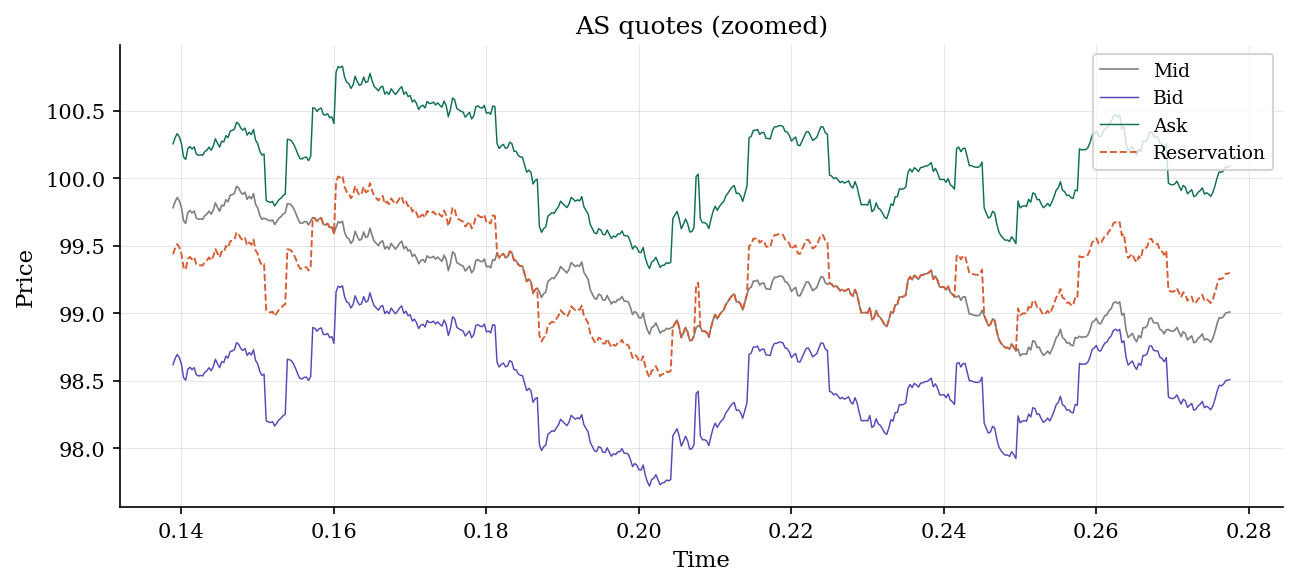

In [14]:
lo, hi = 500, 1000
t_s = result['time'][lo:hi]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_s, result['mid'][lo:hi], color='gray', lw=0.8, label='Mid')
ax.plot(t_s, result['bid'][lo:hi], color=COLORS[0], lw=0.7, label='Bid')
ax.plot(t_s, result['ask'][lo:hi], color=COLORS[1], lw=0.7, label='Ask')
ax.plot(t_s, result['reservation'][lo:hi], color=COLORS[2], ls='--', lw=0.9, label='Reservation')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
ax.set_title('AS quotes (zoomed)')
ax.legend(loc='upper right', fontsize=9)
save_fig(fig, '03_market_making', 'as_quotes')
plt.show()


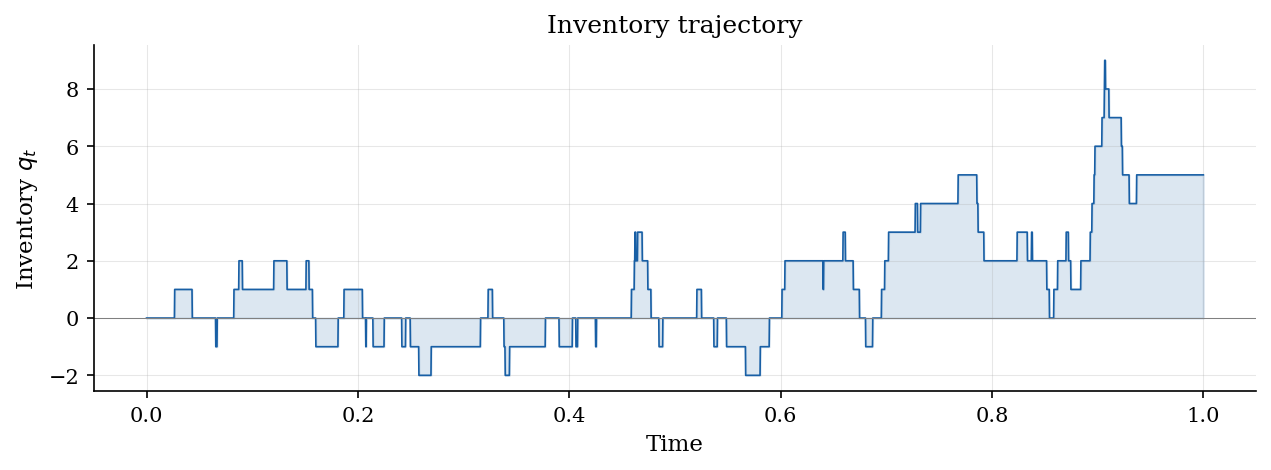

In [15]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(result['time'], result['inventory'], color=COLORS[3], lw=0.8)
ax.axhline(0, color='gray', lw=0.5)
ax.fill_between(result['time'], result['inventory'], 0, alpha=0.15, color=COLORS[3])
ax.set_xlabel('Time')
ax.set_ylabel('Inventory $q_t$')
ax.set_title('Inventory trajectory')
save_fig(fig, '03_market_making', 'as_inventory')
plt.show()


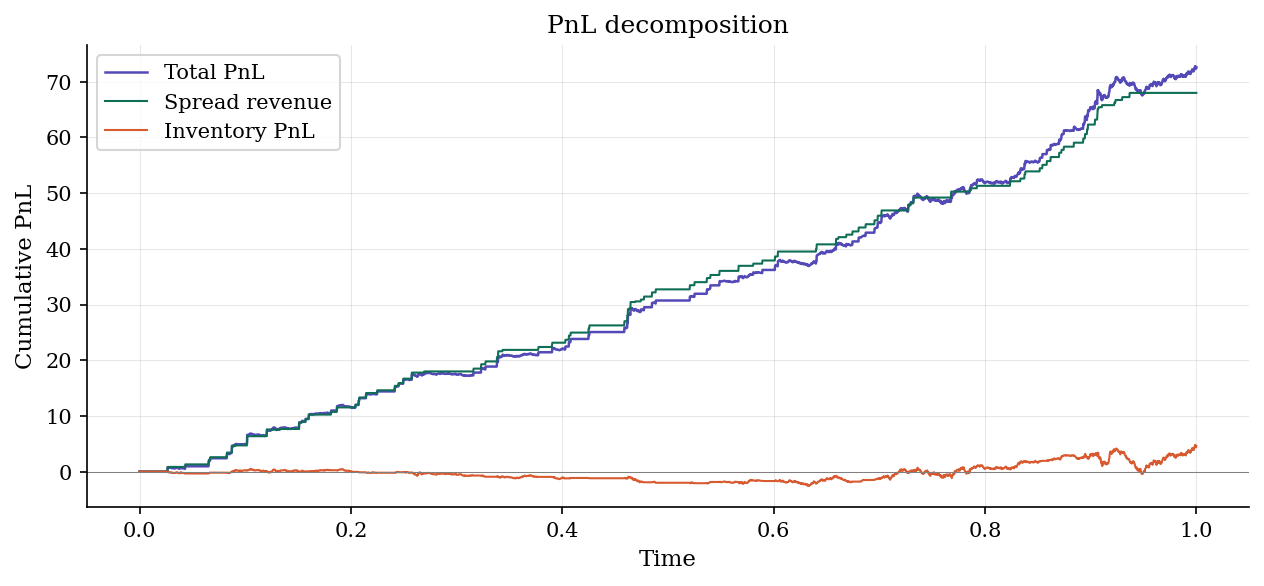

In [16]:
inv_pnl = result['pnl'] - result['spread_revenue']
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result['time'], result['pnl'], color=COLORS[0], lw=1.2, label='Total PnL')
ax.plot(result['time'], result['spread_revenue'], color=COLORS[1], lw=1.0, label='Spread revenue')
ax.plot(result['time'], inv_pnl, color=COLORS[2], lw=1.0, label='Inventory PnL')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative PnL')
ax.set_title('PnL decomposition')
ax.legend()
save_fig(fig, '03_market_making', 'as_pnl_decomposition')
plt.show()


In [17]:
gamma_values = np.logspace(-2, 0, 15)
n_sims = 200
final_pnls = np.zeros((len(gamma_values), n_sims))
for i, g in enumerate(gamma_values):
    for j in range(n_sims):
        sim_rng = np.random.default_rng(1000 * i + j)
        res = avellaneda_stoikov_sim(100.0, 2.0, 1.0, 3600, g, 1.5, 140.0, sim_rng)
        final_pnls[i, j] = res['pnl'][-1]
print('Gamma sweep done.')


Gamma sweep done.


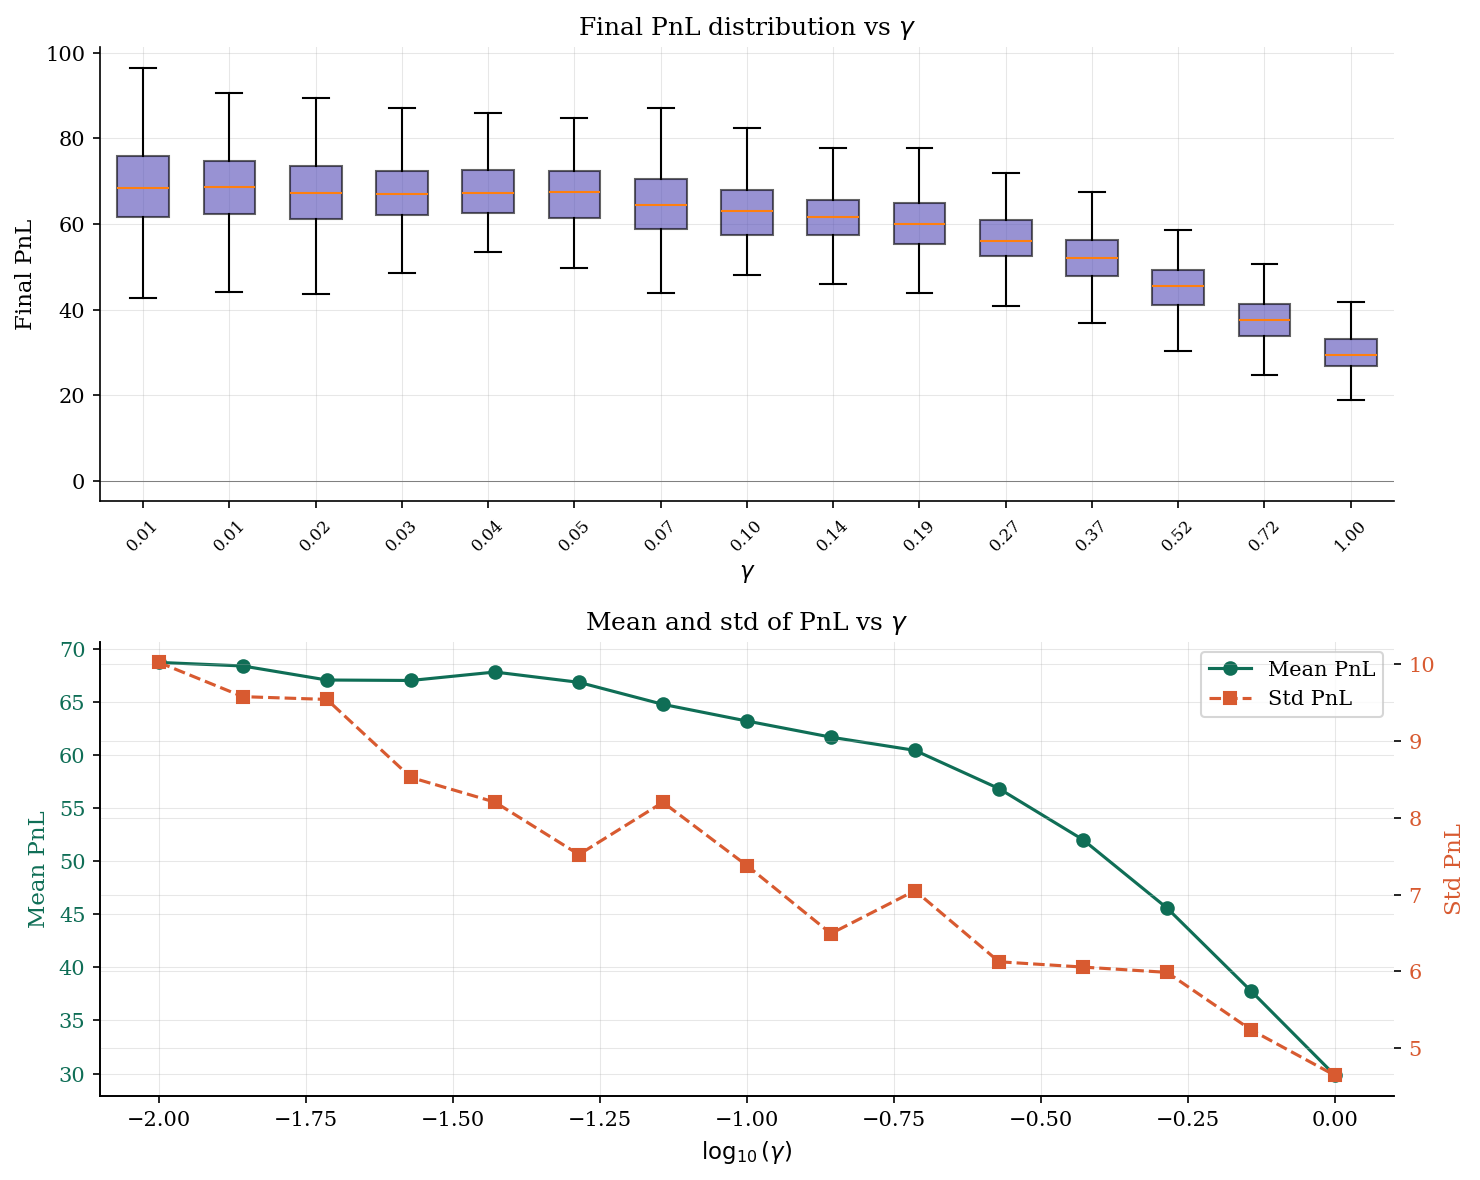

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
bp = ax1.boxplot([final_pnls[i] for i in range(len(gamma_values))],
                 positions=range(len(gamma_values)), widths=0.6,
                 patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS[0])
    patch.set_alpha(0.6)
ax1.set_xticks(range(len(gamma_values)))
ax1.set_xticklabels([f'{g:.2f}' for g in gamma_values], rotation=45, fontsize=8)
ax1.set_xlabel(r'$\gamma$')
ax1.set_ylabel('Final PnL')
ax1.set_title(r'Final PnL distribution vs $\gamma$')
ax1.axhline(0, color='gray', lw=0.5)
means = final_pnls.mean(axis=1)
stds = final_pnls.std(axis=1)
ln_g = np.log10(gamma_values)
ax2.plot(ln_g, means, 'o-', color=COLORS[1], label='Mean PnL')
ax2.set_xlabel(r'$\log_{10}(\gamma)$')
ax2.set_ylabel('Mean PnL', color=COLORS[1])
ax2.tick_params(axis='y', labelcolor=COLORS[1])
ax2b = ax2.twinx()
ax2b.plot(ln_g, stds, 's--', color=COLORS[2], label='Std PnL')
ax2b.set_ylabel('Std PnL', color=COLORS[2])
ax2b.tick_params(axis='y', labelcolor=COLORS[2])
ax2.set_title(r'Mean and std of PnL vs $\gamma$')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
fig.tight_layout()
save_fig(fig, '03_market_making', 'as_gamma_sensitivity')
plt.show()


## Prosperity 4 Takeaways

- **Tune $\gamma$:** Sweep 0.01–1.0 on simulator or backtest — central risk–return knob for inventory vs spread.
- **Estimate $\sigma$:** Rolling realised variance of mid-price returns (e.g. last 50–100 ticks).
- **Estimate $\kappa$, $A$:** Fit $A e^{-\kappa\delta}$ to empirical fill rates vs quote distance.
- **Time to go:** Use remaining round time in $T-t$ so quotes tighten near horizon.
- **Skew quotes:** Add signal term to $r_t$ (e.g. mean-reversion z-score) to combine AS with stat-arb.
